In [1]:
!pip install wordcloud

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/45/70/0041966d469dec79036ad3962b83b007004b842531ee7c41bdba61310eb6/wordcloud-1.9.6-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   ----- --------------------------------- 41.0/306.1 kB 960.0 kB/s eta 0:00:01
   ------------- -------------------------- 102.4/306.1 kB 1.2 MB/s eta 0:00:01
   ------------------------------ --------- 235.5/306.1 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 306.1/306.1 kB 1.9 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from wordcloud import WordCloud, STOPWORDS
import warnings
warnings.filterwarnings('ignore', category = DeprecationWarning)

In [4]:
dataset = pd.read_csv(
    'dataset.csv',
    encoding='latin-1',
    names = ['Sentiment', 'Id', 'Date', 'Flag', 'User', 'Tweet']
)

In [5]:
print(
    "Total tweets in the dataset: {} Million"
    .format(dataset.shape[0]/1000000.0)
)

Total tweets in the dataset: 1.6 Million


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   Sentiment  1600000 non-null  int64 
 1   Id         1600000 non-null  int64 
 2   Date       1600000 non-null  object
 3   Flag       1600000 non-null  object
 4   User       1600000 non-null  object
 5   Tweet      1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


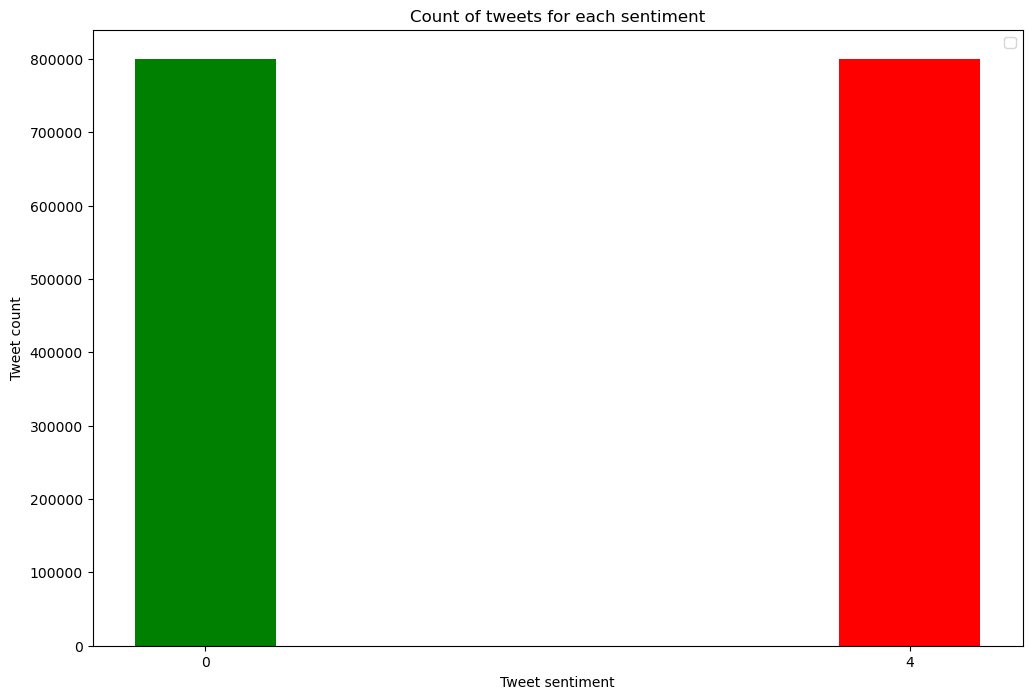

In [7]:
class_count = dataset['Sentiment'].value_counts()
plt.figure(figsize = (12, 8))
plt.xticks([4,0])
plt.bar(
    x = class_count.keys(),
    height = class_count.values,
    color = ['g', 'r']
)
plt.xlabel("Tweet sentiment")
plt.ylabel("Tweet count")
plt.title("Count of tweets for each sentiment")
plt.legend()

Text(0.5, 1.0, 'Tweets during months of 2009')

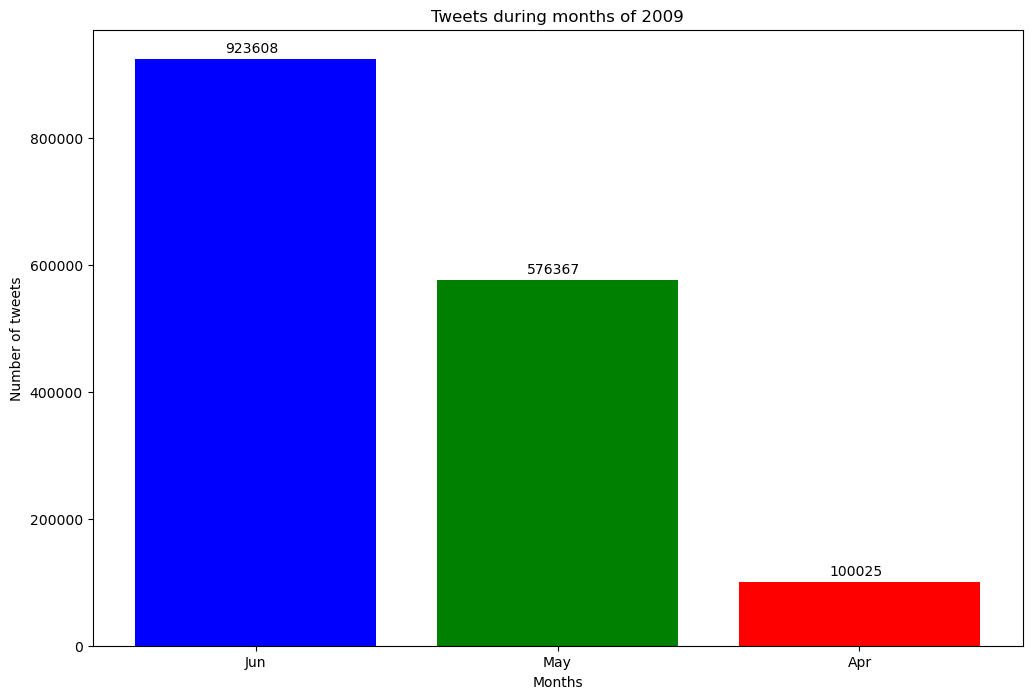

In [9]:
dataset['Month'] = dataset['Date'].apply(
    lambda date: date.split(' ')[1]
)

months_count = dataset['Month'].value_counts()

plt.figure(figsize = (12, 8))
plt.bar(
    ['Jun', 'May', 'Apr'],
    months_count.values,
    color = ['b', 'g', 'r']
)

for i, v in enumerate(months_count.values):
    plt.text(i - 0.1, v + 10000, str(v))
plt.xlabel('Months')
plt.ylabel('Number of tweets')
plt.title('Tweets during months of 2009')

In [10]:
# Display first tweet
print(dataset['Tweet'][0])

@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D


In [11]:
# Display second tweet
print(dataset['Tweet'][1])

is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!


In [12]:
# Combine all positive tweets into one string
positive_tweets = ' '.join(
    dataset[dataset['Sentiment'] == 4]['Tweet'].str.lower()
)


# Combine all negative tweets into one string
negative_tweets = ' '.join(
    dataset[dataset['Sentiment'] == 0]['Tweet'].str.lower()
)

Text(0.5, 1.0, 'Positive tweets Wordcloud')

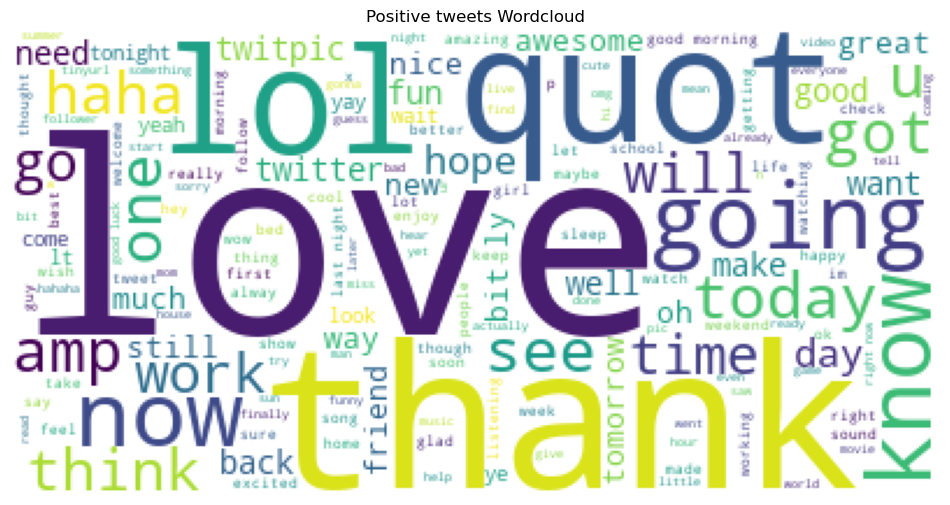

In [13]:
# Create positive tweets wordcloud
wordcloud = WordCloud(
    stopwords = STOPWORDS,
    background_color = "white",
    max_words = 1000
).generate(positive_tweets)

plt.figure(figsize = (12, 8))

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive tweets Wordcloud")

Text(0.5, 1.0, 'Negative tweets Wordcloud')

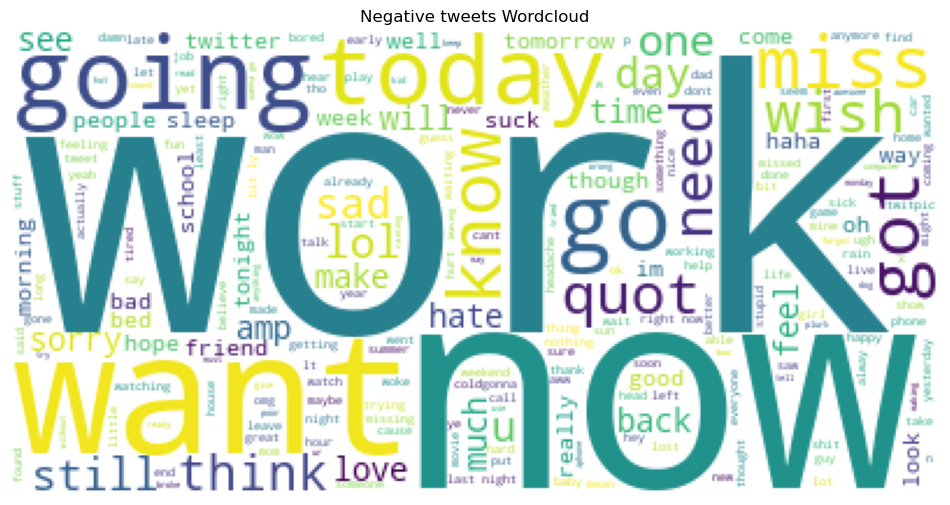

In [14]:
wordcloud = WordCloud(
    stopwords = STOPWORDS,
    background_color = "white",
    max_words = 1000
).generate(negative_tweets)

plt.figure(figsize = (12, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative tweets Wordcloud")